<a href="https://colab.research.google.com/github/danadorn/JS/blob/main/SVM_Breast_Cancer_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab: Support Vector Machines (SVM)** <br>
**Objective**: In this lab, we will explore how SVMs classify data using Hyperplanes, Margins, and Kernels. We will visualize the effects of the parameters $C$ and Gamma ($\gamma$), and finally apply SVM to the Breast Cancer dataset.

In [ ]:
# --- SETUP: Import Libraries & Helper Functions ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# This function visualizes the decision boundaries
def plot_svm_boundary(model, X, y, title='SVM Decision Boundary'):
    # Create grid to evaluate model
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict across the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm, s=50)

    # Highlight support vectors
    if hasattr(model, "support_vectors_"):
        plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=150,
                    linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.show()

print("Setup Complete. Helper function loaded.")

Setup Complete. Helper function loaded.


## **Part 1: The Effect of C (Hard vs. Soft Margin)**

The parameter C controls how strictly the SVM punishes misclassifications.

High C: Hard Margin (Strict, risks overfitting).

Low C: Soft Margin (Smoother, tolerates outliers).

Run the code below to see how the boundary changes.

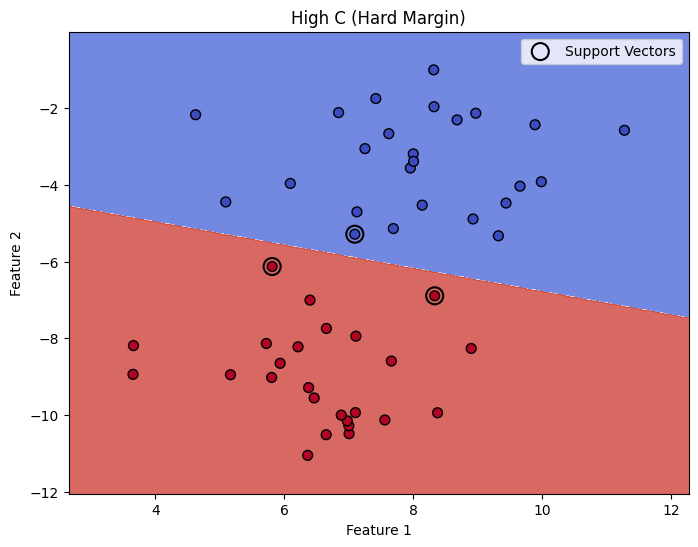

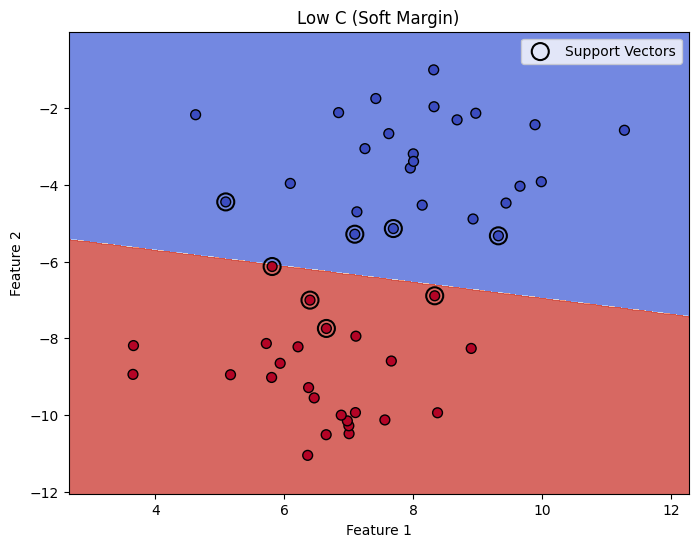

In [ ]:
from sklearn.datasets import make_blobs

# 1. Generate Data with some noise
X, y = make_blobs(n_samples=50, centers=2, random_state=6, cluster_std=1.3)

# 2. High C (Strict)
# Try changing C to 1000
clf_high = svm.SVC(kernel='linear', C=1000)
clf_high.fit(X, y)
plot_svm_boundary(clf_high, X, y, title='High C (Hard Margin)')

# 3. Low C (Loose)
# Try changing C to 0.1
clf_low = svm.SVC(kernel='linear', C=0.1)
clf_low.fit(X, y)
plot_svm_boundary(clf_low, X, y, title='Low C (Soft Margin)')

## **Part 2: Non-Linear Data (The Kernel Trick)**

Sometimes a straight line cannot separate classes. We use Kernels (like RBF) to project data into higher dimensions where they become separable.

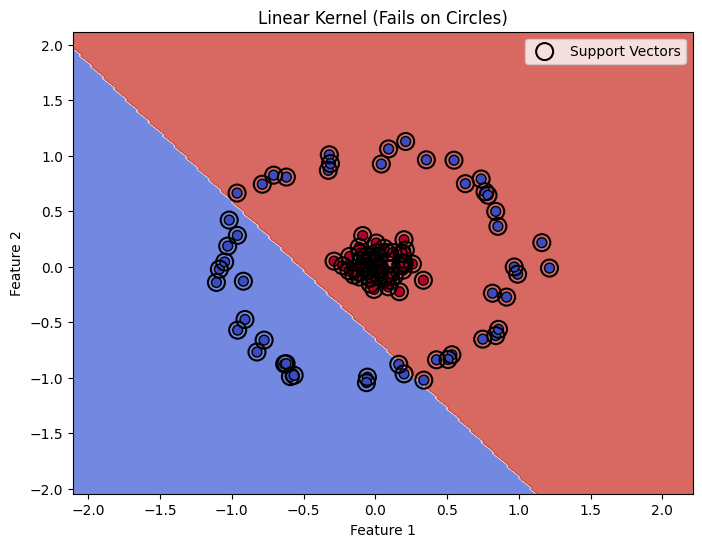

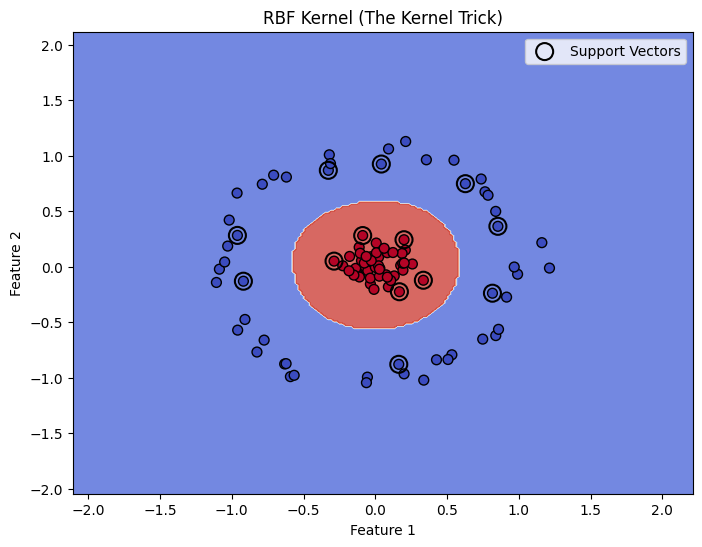

In [ ]:
from sklearn.datasets import make_circles

# 1. Generate Circle Data
X_circle, y_circle = make_circles(n_samples=100, factor=0.1, noise=0.1)

# 2. Linear Kernel (This will fail)
clf_lin = svm.SVC(kernel='linear')
clf_lin.fit(X_circle, y_circle)
plot_svm_boundary(clf_lin, X_circle, y_circle, title='Linear Kernel (Fails on Circles)')

# 3. RBF Kernel (This works!)
clf_rbf = svm.SVC(kernel='rbf', C=1)
clf_rbf.fit(X_circle, y_circle)
plot_svm_boundary(clf_rbf, X_circle, y_circle, title='RBF Kernel (The Kernel Trick)')

## **Part 3: The Gamma Parameter ($\gamma$)**

Gamma controls the distance of influence of a single training point.

**Low Gamma:** High reach (Smooth boundary).

**High Gamma:** Short reach (Creates "islands" around points -> Overfitting).

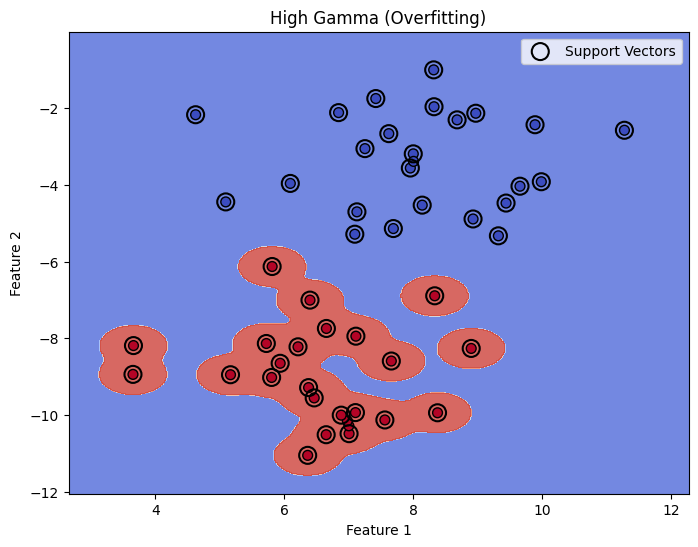

In [ ]:
# High Gamma Experiment
# Change gamma to 10 or 100 to see extreme overfitting
clf_high_g = svm.SVC(kernel='rbf', gamma=10)
clf_high_g.fit(X, y) # Using the blob data again
plot_svm_boundary(clf_high_g, X, y, title='High Gamma (Overfitting)')

## Part 4: Real World Data (Breast Cancer Dataset)

**Crucial Step:** In this section, you must process the data correctly. Remember that SVMs are distance-based, so the scale of the data matters immenseley. You also need to instantiate the model, train it, and generate predictions.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. Load and Split Data (Already done for you)
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# SVMs are sensitive to scale! We must normalize the data.
scaler = StandardScaler()

# TODO: Fit the scaler on the training data and transform X_train
# Hint: Use .fit_transform()
X_train_scaled = None # <--- REPLACE 'None' WITH CODE

# TODO: Transform the test data (X_test) using the SAME scaler
# Hint: Do NOT fit again! Just use .transform()
X_test_scaled = None # <--- REPLACE 'None' WITH CODE


# TODO: Initialize the SVM Classifier with a 'rbf' kernel
model = None # <--- REPLACE 'None' WITH CODE

# TODO: Fit the model to the SCALED training data
# (Write your code here)

# TODO: Use the model to predict labels for the SCALED test data
predictions = None # <--- REPLACE 'None' WITH CODE


# --- Evaluation ---
# (Check if predictions exist to avoid errors)
if predictions is not None:
    print(classification_report(y_test, predictions))
else:
    print("Error: Please complete the TODOs above to generate predictions.")

Error: Please complete the TODOs above to generate predictions.


## **Part 5: Hyperparameter Tuning**

Your model is good, but can it be better? Use GridSearchCV to automate the process of finding the best $C$ and $\gamma$ to maximize accuracy.

**Task**: Fill in the param_grid and run the block.

In [ ]:
from sklearn.model_selection import GridSearchCV


# TODO: Create a dictionary called 'param_grid'
# It needs to test:
# 1. 'C': Try values [0.1, 1, 10, 100]
# 2. 'gamma': Try values [1, 0.1, 0.01, 0.001]
# 3. 'kernel': Fixed to ['rbf']
param_grid = {
    # Write your dictionary key-value pairs here
}


# TODO: Initialize GridSearchCV
# Pass your model (SVC) and the param_grid you just defined.
# Set refit=True and verbose=2 so you can see the progress.
grid = None # <--- REPLACE 'None' WITH CODE

# TODO: Fit the 'grid' object to the SCALED training data
# (Write your code here)


# --- Evaluation ---
if grid is not None:
    print(f"Best Parameters: {grid.best_params_}")
    grid_predictions = grid.predict(X_test_scaled)
    print(classification_report(y_test, grid_predictions))
else:
    print("Error: Please initialize the Grid Search object.")

Error: Please initialize the Grid Search object.


# Task
Scale the training data (`X_train`) and transform it to `X_train_scaled` using `StandardScaler`. Then, transform the test data (`X_test`) to `X_test_scaled` using the same fitted scaler. Initialize an `SVC` model with an 'rbf' kernel, fit it to `X_train_scaled` and `y_train`, and make predictions on `X_test_scaled`. Afterward, define a `param_grid` for `GridSearchCV` to tune the `SVC` model, including 'C' values `[0.1, 1, 10, 100]`, 'gamma' values `[1, 0.1, 0.01, 0.001]`, and 'kernel' fixed to `['rbf']`. Initialize `GridSearchCV` with the `SVC` model, the `param_grid`, `refit=True`, and `verbose=2`, and fit it to the `X_train_scaled` and `y_train` data. Finally, display the best parameters found by `GridSearchCV` and the classification report for the optimized model on the test data.

## Scale Training Data

### Subtask:
Fit the StandardScaler on the training data (X_train) and transform it to create X_train_scaled.


**Reasoning**:
The subtask requires scaling the training data by fitting the scaler and transforming `X_train` to `X_train_scaled` using `fit_transform`.



In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. Load and Split Data (Already done for you)
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# SVMs are sensitive to scale! We must normalize the data.
scaler = StandardScaler()

# TODO: Fit the scaler on the training data and transform X_train
# Hint: Use .fit_transform()
X_train_scaled = scaler.fit_transform(X_train) # <--- REPLACE 'None' WITH CODE

# TODO: Transform the test data (X_test) using the SAME scaler
# Hint: Do NOT fit again! Just use .transform()
X_test_scaled = None # <--- REPLACE 'None' WITH CODE


# TODO: Initialize the SVM Classifier with a 'rbf' kernel
model = None # <--- REPLACE 'None' WITH CODE

# TODO: Fit the model to the SCALED training data
# (Write your code here)

# TODO: Use the model to predict labels for the SCALED test data
predictions = None # <--- REPLACE 'None' WITH CODE


# --- Evaluation ---
# (Check if predictions exist to avoid errors)
if predictions is not None:
    print(classification_report(y_test, predictions))
else:
    print("Error: Please complete the TODOs above to generate predictions.")

Error: Please complete the TODOs above to generate predictions.
